# Lesson 4 — Descriptive EDA

Exploratory Data Analysis to understand the distribution of key variables
and identify initial patterns related to employee attrition.

In [1]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Global style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Load the clean dataset
df = pd.read_csv("../data/processed/hr_attrition_clean.csv")

print(df.shape)
df.head()

(1470, 32)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,2,...,3,1,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,2,3,...,4,4,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,4,4,...,3,2,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,5,4,...,3,3,0,8,3,3,8,7,3,0
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,7,1,...,3,4,1,6,3,3,2,2,2,2


In [3]:
count = df['Attrition'].sum()
percentage = df['Attrition'].mean() * 100

print(f"Employees who left: {count}")
print(f"Attrition rate: {percentage:.1f}%")

Employees who left: 237
Attrition rate: 16.1%


## Attrition Rate Overview

**Key finding:** 237 out of 1,470 employees left the company — an attrition rate of **16.1%**.

Industry benchmark for healthy attrition sits around 10–15%, meaning this company 
is slightly above the threshold. While not critical, this signals the importance of 
understanding the root causes to design targeted retention strategies.

In [9]:
attrition_by_dept = df.groupby('Department')['Attrition'].agg(['mean', 'sum'])
attrition_by_dept['mean'] = (attrition_by_dept['mean'] * 100).round(1)
attrition_by_dept.columns = ['Attrition Rate (%)', 'Employees Left']
print(attrition_by_dept.sort_values('Attrition Rate (%)', ascending=False))

                        Attrition Rate (%)  Employees Left
Department                                                
Sales                                 20.6              92
Human Resources                       19.0              12
Research & Development                13.8             133


## Attrition by Department

**Key finding:** Sales (20.6%) and Human Resources (19.0%) show the highest attrition rates,
while Research & Development remains significantly lower at 13.8%.

Departments with direct people-facing responsibilities appear more vulnerable to attrition.
This pattern is consistent with the concept of **emotional labor** — employees who constantly
manage interpersonal interactions are at higher risk of burnout. Additionally, role ambiguity
in Sales and HR may contribute to lower job satisfaction compared to the clearer objectives
typical of R&D roles.

**Business implication:** retention strategies should prioritize Sales and HR departments,
focusing on workload management and role clarity.

In [11]:
attrition_by_role = df.groupby('JobRole')['Attrition'].agg(['mean', 'sum'])
attrition_by_role['mean'] = (attrition_by_role['mean'] * 100).round(1)
attrition_by_role.columns = ['Attrition Rate (%)', 'Employees Left']
print(attrition_by_role.sort_values('Attrition Rate (%)', ascending=False))

                           Attrition Rate (%)  Employees Left
JobRole                                                      
Sales Representative                     39.8              33
Laboratory Technician                    23.9              62
Human Resources                          23.1              12
Sales Executive                          17.5              57
Research Scientist                       16.1              47
Healthcare Representative                 6.9               9
Manufacturing Director                    6.9              10
Manager                                   4.9               5
Research Director                         2.5               2


## Attrition by Job Role

**Key finding:** The three roles with the highest attrition are Sales Representative (39.8%),
Laboratory Technician (23.9%), and Human Resources (23.1%). Conversely, senior roles such as
Research Director (2.5%) and Manager (4.9%) show the lowest attrition rates.

This pattern is consistent with the **Self-Determination Theory**: employees tend to leave
when they perceive low autonomy, limited growth opportunities, and insufficient recognition —
all characteristics associated with entry-level positions.

**Business implication:** retention efforts should focus on career development programs
for junior roles, including clear promotion paths and recognition initiatives.


In [12]:
attrition_by_numeric = df.groupby('Attrition')[['Age', 'MonthlyIncome', 'YearsAtCompany']].mean().round(1)
print(attrition_by_numeric)

            Age  MonthlyIncome  YearsAtCompany
Attrition                                     
0          37.6         6832.7             7.4
1          33.6         4787.1             5.1


## Attrition by Age, Monthly Income and Years at Company

**Key finding:** Employees who left show consistently lower values across all three variables:
younger age (33.6 vs 37.6), lower monthly income ($4,787 vs $6,833), and fewer years
at the company (5.1 vs 7.4).

These three variables are strongly correlated with attrition. However, it is important
to note that **correlation does not imply causation** — younger employees tend to have
less experience and lower salaries, making it difficult to isolate a single root cause.
The combination of these factors likely creates a compounded effect on job dissatisfaction.

**Business implication:** targeted retention programs for junior, lower-income employees
in their first 5 years could significantly reduce overall attrition.

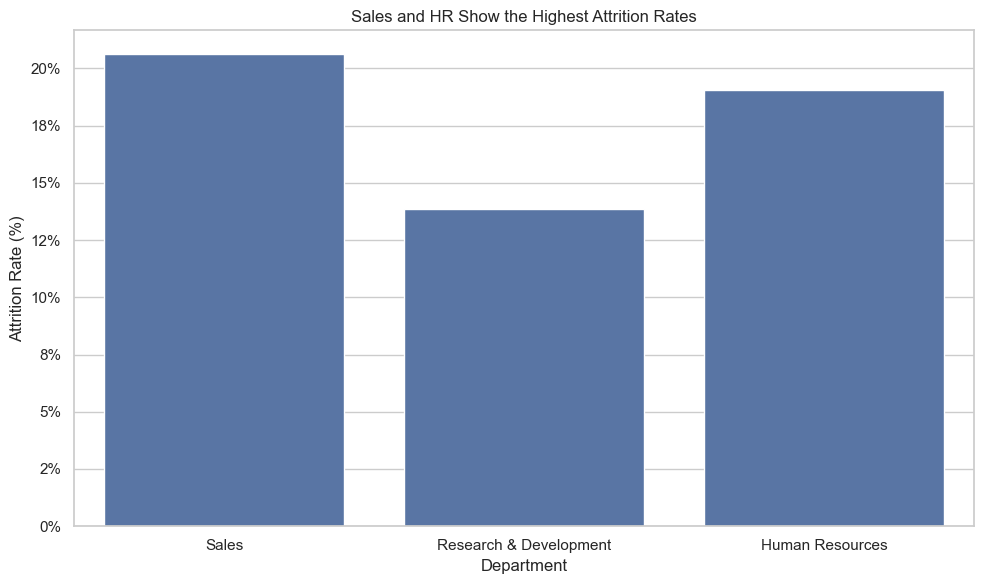

In [18]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='Department', y='Attrition', errorbar=None)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x*100:.0f}%'))
plt.title('Sales and HR Show the Highest Attrition Rates')
plt.xlabel('Department')
plt.ylabel('Attrition Rate (%)')
plt.tight_layout()
plt.savefig('../reports/01_attrition_by_department.png', dpi=150, bbox_inches='tight')
plt.show()